# LION Experiment Plots

Fetches the `final_results` group from W&B project `jfcevallos/LION`,
groups the 90 runs (9 agents × 10 seeds) by the `agent` config parameter,
and plots mean ± 95 % CI across seeds for key metrics.

**Requires** a `.env` file in the same directory containing:
```
WANDB_API_KEY=<your_key>
```

In [1]:
import os
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from dotenv import load_dotenv

import wandb

warnings.filterwarnings('ignore', category=FutureWarning)

## Utils

In [2]:
# ── Typography ──────────────────────────────────────────────────────────────
title_font  = {'weight': 'bold', 'size': 22}
axis_font   = {'weight': 'bold', 'size': 18}
legend_font = {'weight': 'bold', 'size': 18}


def get_color_map(agents):
    """
    Prefer the hard-coded per-agent colours used in synthetic_lion.py,
    falling back to tab10 for any unknown name.
    """
    hardcoded = {
        'DDQN':         '#2196F3',
        'Dueling-DDQN': '#00BCD4',
        'PPO':          '#FF5722',
        'SAC':          '#8BC34A',
        'DAI-P':        '#E91E63',
        'DAI-A':        '#FF9800',
        'DAI-SA':       '#9C27B0',
        'DAI-F':        '#4CAF50',
        'Break-Even':   '#607D8B',
    }
    fallback = itertools.cycle(plt.colormaps.get_cmap('tab10').colors)
    return {a: hardcoded.get(a, next(fallback)) for a in agents}


def compute_ci_band(histories: list[pd.Series], alpha: float = 0.95):
    """
    Given a list of per-seed time-series (indexed by episode step),
    return (mean, lower_ci, upper_ci) aligned to a common step range.

    Uses a *t*-distribution-based 95 % CI:
        mean ± t_{n-1, 0.975} * std / sqrt(n)
    Falls back to ±std when n < 2.
    """
    from scipy import stats as scipy_stats

    if not histories:
        return None, None, None

    # Align all series to a shared integer index (episode number)
    combined = pd.concat(histories, axis=1)
    combined = combined.apply(pd.to_numeric, errors='coerce')

    mean = combined.mean(axis=1)
    std  = combined.std(axis=1, ddof=1)
    n    = combined.notna().sum(axis=1)

    # t multiplier per row (gracefully handles n=1 by returning nan CI)
    t_mult = pd.Series(
        [scipy_stats.t.ppf((1 + alpha) / 2, df=max(ni - 1, 1)) if ni > 1 else float('nan')
         for ni in n],
        index=mean.index
    )
    margin = t_mult * std / np.sqrt(n)
    return mean, mean - margin, mean + margin


def _style_ax(ax, title, xlabel, ylabel=None, ylim=None):
    """Apply consistent styling to a subplot axis."""
    ax.set_title(title, **title_font)
    ax.set_xlabel(xlabel, **axis_font)
    if ylabel:
        ax.set_ylabel(ylabel, **axis_font)
    ax.tick_params(axis='both', labelsize=axis_font['size'])
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.4)


def plot_metric_grid(
    agent_data: dict,
    metrics: list,
    n_cols: int = 2,
    title: str = '',
    smooth_window: int = 10,
    figsize_per_cell=(10, 4),
    agent_subset=None,
):
    """
    Draws a grid of subplots, one per metric in `metrics`.

    agent_data  : {agent_name: pd.DataFrame (index=episode, columns=metrics)}
    metrics     : list of dicts with keys: key, title, ylim (opt), xlabel (opt)
    n_cols      : number of grid columns
    smooth_window : rolling-mean window applied *before* CI aggregation is shown
    agent_subset  : if given, only plot these agents
    """
    agents_to_plot = agent_subset if agent_subset else list(agent_data.keys())
    color_map = get_color_map(agents_to_plot)

    n_metrics = len(metrics)
    n_rows    = (n_metrics + n_cols - 1) // n_cols
    fig_w, fig_h = figsize_per_cell
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(fig_w * n_cols, fig_h * n_rows),
        squeeze=False
    )
    axes_flat = axes.flatten()

    for i, metric in enumerate(metrics):
        ax  = axes_flat[i]
        key = metric['key']

        for agent in agents_to_plot:
            runs_df = agent_data.get(agent)
            if runs_df is None or key not in runs_df.columns:
                continue

            # Each seed is a column; smooth each seed independently
            smoothed = runs_df[key].rolling(smooth_window, min_periods=1).mean()

            # Rebuild as list of per-seed series for CI computation
            seed_series = [smoothed[col].dropna() for col in smoothed.columns]
            mean, lo, hi = compute_ci_band(seed_series)

            if mean is None:
                continue

            color = color_map[agent]
            ax.plot(mean.index, mean.values, label=agent, color=color,
                    linewidth=2, alpha=0.9)
            if lo is not None:
                ax.fill_between(lo.index, lo.values, hi.values,
                                color=color, alpha=0.18)

        _style_ax(
            ax,
            title=metric.get('title', key),
            xlabel=metric.get('xlabel', 'Episode'),
            ylabel=metric.get('ylabel', metric.get('title', key)),
            ylim=metric.get('ylim'),
        )

    # Hide unused subplot cells
    for j in range(n_metrics, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared legend below the figure
    handles = [Line2D([0], [0], color=color_map[a], lw=2, label=a)
               for a in agents_to_plot if a in color_map]
    fig.legend(
        handles=handles,
        prop=legend_font,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.04),
        ncol=min(len(agents_to_plot), 5),
        frameon=True,
    )

    if title:
        fig.suptitle(title, weight='bold', size=26, y=1.01)

    plt.tight_layout()
    plt.show()

## Setup: W&B API

In [3]:
load_dotenv()   # reads WANDB_API_KEY from .env

api = wandb.Api()
print('W&B API initialised')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


W&B API initialised


## Fetch Runs  (group = `final_results`)

In [4]:
WANDB_PROJECT = 'jfcevallos/LION'
GROUP         = 'final_results_5'
N_SAMPLES     = 10_000   # history samples per run (W&B cap; raise if needed)

all_runs = api.runs(
    WANDB_PROJECT,
    filters={'group': GROUP},
)
print(f'Found {len(all_runs)} runs in group "{GROUP}"')

Found 90 runs in group "final_results_5"


In [5]:
# ── Fetch histories, keyed by (agent, seed) ─────────────────────────────────
#
# W&B config stores 'agent' and 'seed' as custom params set in synthetic_lion.py:
#   config={..., 'seed': seed, 'agent': agent_name}

raw_runs = {}   # {(agent_name, seed): pd.DataFrame}

for run in all_runs:
    agent_name = run.config.get('agent', run.job_type or 'unknown')
    seed       = run.config.get('seed', -1)
    print(f'  fetching  {agent_name:12s}  seed={seed}  ({run.id})')

    hist = run.history(samples=N_SAMPLES)
    if '_step' in hist.columns:
        hist = hist.set_index('_step')
    elif hist.index.name != '_step':
        hist.index.name = 'episode'

    raw_runs[(agent_name, seed)] = hist

print(f'\nFetched {len(raw_runs)} runs total')

  fetching  PPO           seed=0  (f82w7jbk)
  fetching  DDQN          seed=0  (iz8x80r7)
  fetching  SAC           seed=0  (l24wdo26)
  fetching  Dueling-DDQN  seed=0  (uvbk3aqn)
  fetching  DAI-P         seed=0  (ag0z1ltf)
  fetching  DAI-A         seed=0  (gyik0qdp)
  fetching  DAI-SA        seed=0  (cgj46qc6)
  fetching  DAI-F         seed=0  (ncm7k4xm)
  fetching  Break-Even    seed=0  (rn9g7diu)
  fetching  Dueling-DDQN  seed=1  (97nqudee)
  fetching  DDQN          seed=1  (j3x0pcqf)
  fetching  PPO           seed=1  (1tupwzks)
  fetching  SAC           seed=1  (f7em231q)
  fetching  DAI-P         seed=1  (zvx9ogz1)
  fetching  DAI-SA        seed=1  (s6th1xqb)
  fetching  DAI-A         seed=1  (ipx54jqx)
  fetching  DAI-F         seed=1  (j7s0mjty)
  fetching  Break-Even    seed=1  (vpkrf90e)
  fetching  Dueling-DDQN  seed=2  (g93xb8vn)
  fetching  DDQN          seed=2  (kyt6f1ee)
  fetching  PPO           seed=2  (9auhc97y)
  fetching  SAC           seed=2  (o3x4gekj)
  fetching

In [6]:
# ── Organise into agent_data:
#    {agent_name: {metric_col: DataFrame(index=episode, columns=seeds)}}
#
# We keep a *wide* DataFrame per agent where each column is one seed.
# This makes vectorised CI computation straightforward.

from collections import defaultdict

# First pass: discover all agents and all metric columns
agents_found = sorted({k[0] for k in raw_runs})
all_cols     = sorted({col for df in raw_runs.values() for col in df.columns})

print('Agents found:', agents_found)
print('\nMetric columns available:')
for c in all_cols:
    print(' ', c)

# Second pass: build per-agent wide DataFrames  {agent: {col: wide_df}}
agent_data = {}   # agent_name -> wide DataFrame (index=episode, columns=seed_id)

for agent in agents_found:
    seed_dfs = {seed: df for (ag, seed), df in raw_runs.items() if ag == agent}
    if not seed_dfs:
        continue

    # Build one wide df per metric column
    # We store a single wide df where column tuples are (metric, seed)
    all_seed_dfs = [df.add_suffix(f'__seed{s}') for s, df in seed_dfs.items()]
    wide = pd.concat(all_seed_dfs, axis=1).sort_index()
    agent_data[agent] = wide

print(f'\nBuilt wide DataFrames for {len(agent_data)} agents')

Agents found: ['Break-Even', 'DAI-A', 'DAI-F', 'DAI-P', 'DAI-SA', 'DDQN', 'Dueling-DDQN', 'PPO', 'SAC']

Metric columns available:
  _runtime
  _timestamp
  budget_final
  classification_reward
  clustering_reward
  cti_cost
  epistemic_gains/accept
  epistemic_gains/block
  epistemic_gains/buy_A
  epistemic_gains/buy_B
  epistemic_gains/buy_C
  epistemic_gains/buy_D
  epistemic_gains/buy_label
  epistemic_gains/mean
  inference_confidence
  label_A
  loss
  n_labels
  n_steps
  reward
  reward_sum
  trans_loss
  unk_confs/A
  unk_confs/B
  unk_confs/C
  unk_confs/D
  win

Built wide DataFrames for 9 agents


In [7]:
# ── Helper: extract per-metric wide DataFrame for a specific metric key ───
#
# Returns {agent: DataFrame(index=episode, columns=seed_ids)}

def get_metric_wide(metric_key: str) -> dict:
    result = {}
    for agent, wide in agent_data.items():
        cols = [c for c in wide.columns if c.startswith(metric_key + '__seed')]
        if not cols:
            continue
        result[agent] = wide[cols].copy()
        result[agent].columns = [c.split('__seed')[1] for c in cols]  # seed id as col name
    return result


# Quick sanity check
rew_wide = get_metric_wide('reward')
print('reward wide shapes:', {a: df.shape for a, df in rew_wide.items()})

reward wide shapes: {'Break-Even': (500, 10), 'DAI-A': (500, 10), 'DAI-F': (500, 10), 'DAI-P': (500, 10), 'DAI-SA': (500, 10), 'DDQN': (500, 10), 'Dueling-DDQN': (500, 10), 'PPO': (500, 10), 'SAC': (500, 10)}


## Plotting helper (CI-aware)
  
we compute a proper **95 % confidence interval across the 10 seeds** for each agent.

In [8]:
from scipy import stats as scipy_stats

def plot_metric_grid_v2(
    metrics: list,
    n_cols: int = 2,
    suptitle: str = '',
    smooth_window: int = 15,
    figsize_per_cell=(10, 4),
    agent_subset=None,
    ci_alpha: float = 0.95,
):
    """
    metrics: list of dicts
        - key      : wandb metric name
        - title    : subplot title
        - ylim     : (lo, hi) or None
        - xlabel   : x-axis label (default 'Episode')
        - ylabel   : y-axis label (default title)
    """
    agents_to_plot = agent_subset if agent_subset else agents_found
    color_map      = get_color_map(agents_to_plot)

    n_metrics = len(metrics)
    n_rows    = (n_metrics + n_cols - 1) // n_cols
    fw, fh    = figsize_per_cell
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(fw * n_cols, fh * n_rows),
                             squeeze=False)
    axes_flat = axes.flatten()

    for i, metric in enumerate(metrics):
        ax   = axes_flat[i]
        key = metric['key']

        metric_wide = get_metric_wide(key)

        for agent in agents_to_plot:
            wide = metric_wide.get(agent)
            if wide is None or wide.empty:
                continue

            # Convert to numeric and smooth each seed
            wide_num = wide.apply(pd.to_numeric, errors='coerce')
            wide_smoothed = wide_num.rolling(smooth_window, min_periods=1).mean()

            # CI across seeds
            vals  = wide_smoothed.values      # shape (episodes, n_seeds)
            idx   = wide_smoothed.index
            n     = np.sum(~np.isnan(vals), axis=1)
            mean  = np.nanmean(vals, axis=1)
            std   = np.nanstd(vals, axis=1, ddof=1)

            # t-based margin
            t_mult = np.where(
                n > 1,
                scipy_stats.t.ppf((1 + ci_alpha) / 2, df=np.maximum(n - 1, 1)),
                np.nan
            )
            margin = t_mult * std / np.sqrt(np.maximum(n, 1))

            color = color_map[agent]
            ax.plot(idx, mean, label=agent, color=color, linewidth=2, alpha=0.9)
            ax.fill_between(idx, mean - margin, mean + margin,
                            color=color, alpha=0.18)

        _style_ax(
            ax,
            title=metric.get('title', key),
            xlabel=metric.get('xlabel', 'Episode'),
            ylabel=metric.get('ylabel', metric.get('title', key)),
            ylim=metric.get('ylim'),
        )

    for j in range(n_metrics, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Single legend below the grid
    handles = [Line2D([0], [0], color=color_map[a], lw=2, label=a)
               for a in agents_to_plot if a in color_map]
    # Add CI shading swatch to legend
    ci_patch = mpatches.Patch(alpha=0.3, color='grey',
                               label=f'mean {int(ci_alpha*100)}% CI (across 10 seeds)')
    fig.legend(
        handles=handles + [ci_patch],
        prop=legend_font,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=min(len(agents_to_plot) + 1, 5),
        frameon=True,
    )

    if suptitle:
        fig.suptitle(suptitle, weight='bold', size=26, y=1.02)

    plt.tight_layout()
    plt.show()

---
## Grid Plot 1 — Core Performance Metrics

Reward, win rate, number of labels bought, label-A purchase rate, final budget, and training loss  
averaged across 10 seeds with 95 % confidence intervals.

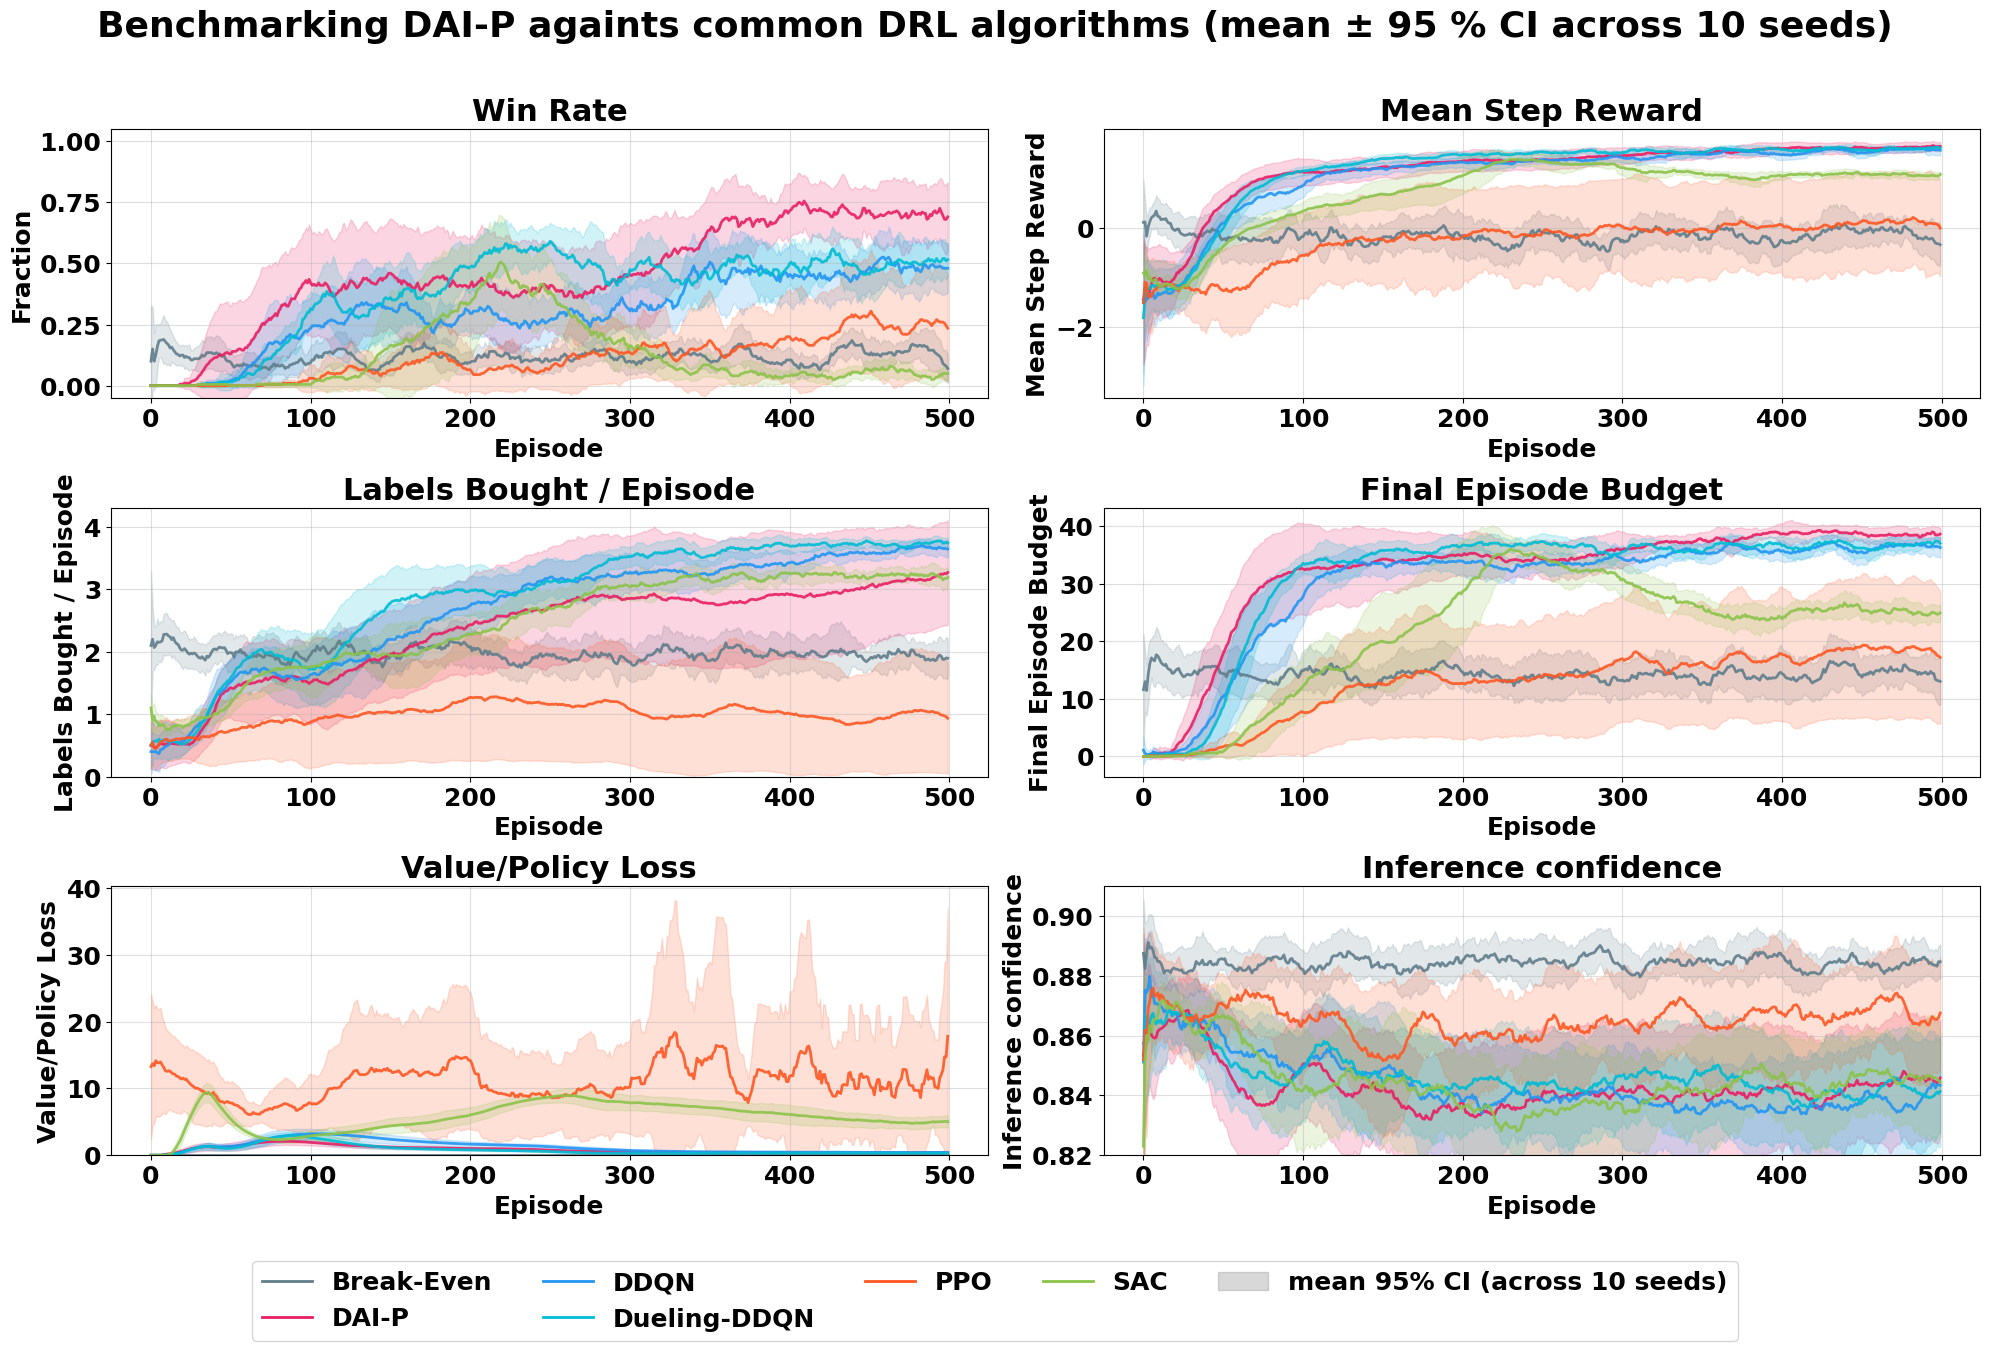

In [ ]:
perf_metrics = [
    {'key': 'win',          'title': 'Win Rate',                 'ylim': (-0.05, 1.05), 'ylabel': 'Fraction'},
    {'key': 'reward',       'title': 'Mean Step Reward',         'ylim': None},
    {'key': 'n_labels',     'title': 'Labels Bought / Episode',  'ylim': (0, None)},
    {'key': 'budget_final', 'title': 'Final Episode Budget',     'ylim': None},
    {'key': 'loss',         'title': 'Value/Policy Loss',            'ylim': (0, None)},
    {'key': 'inference_confidence', 'title': 'Inference confidence',     'ylim': (0.82,0.91)},

]

# Filter agents to include only non-DAI agents and DAI-P
filtered_agents = [agent for agent in agents_found if not agent.startswith('DAI') or agent == 'DAI-P']

plot_metric_grid_v2(
    metrics=perf_metrics,
    n_cols=2,
    suptitle='Benchmarking DAI-P againts common DRL algorithms (mean ± 95 % CI across 10 seeds)',
    smooth_window=20,
    agent_subset=filtered_agents,
)

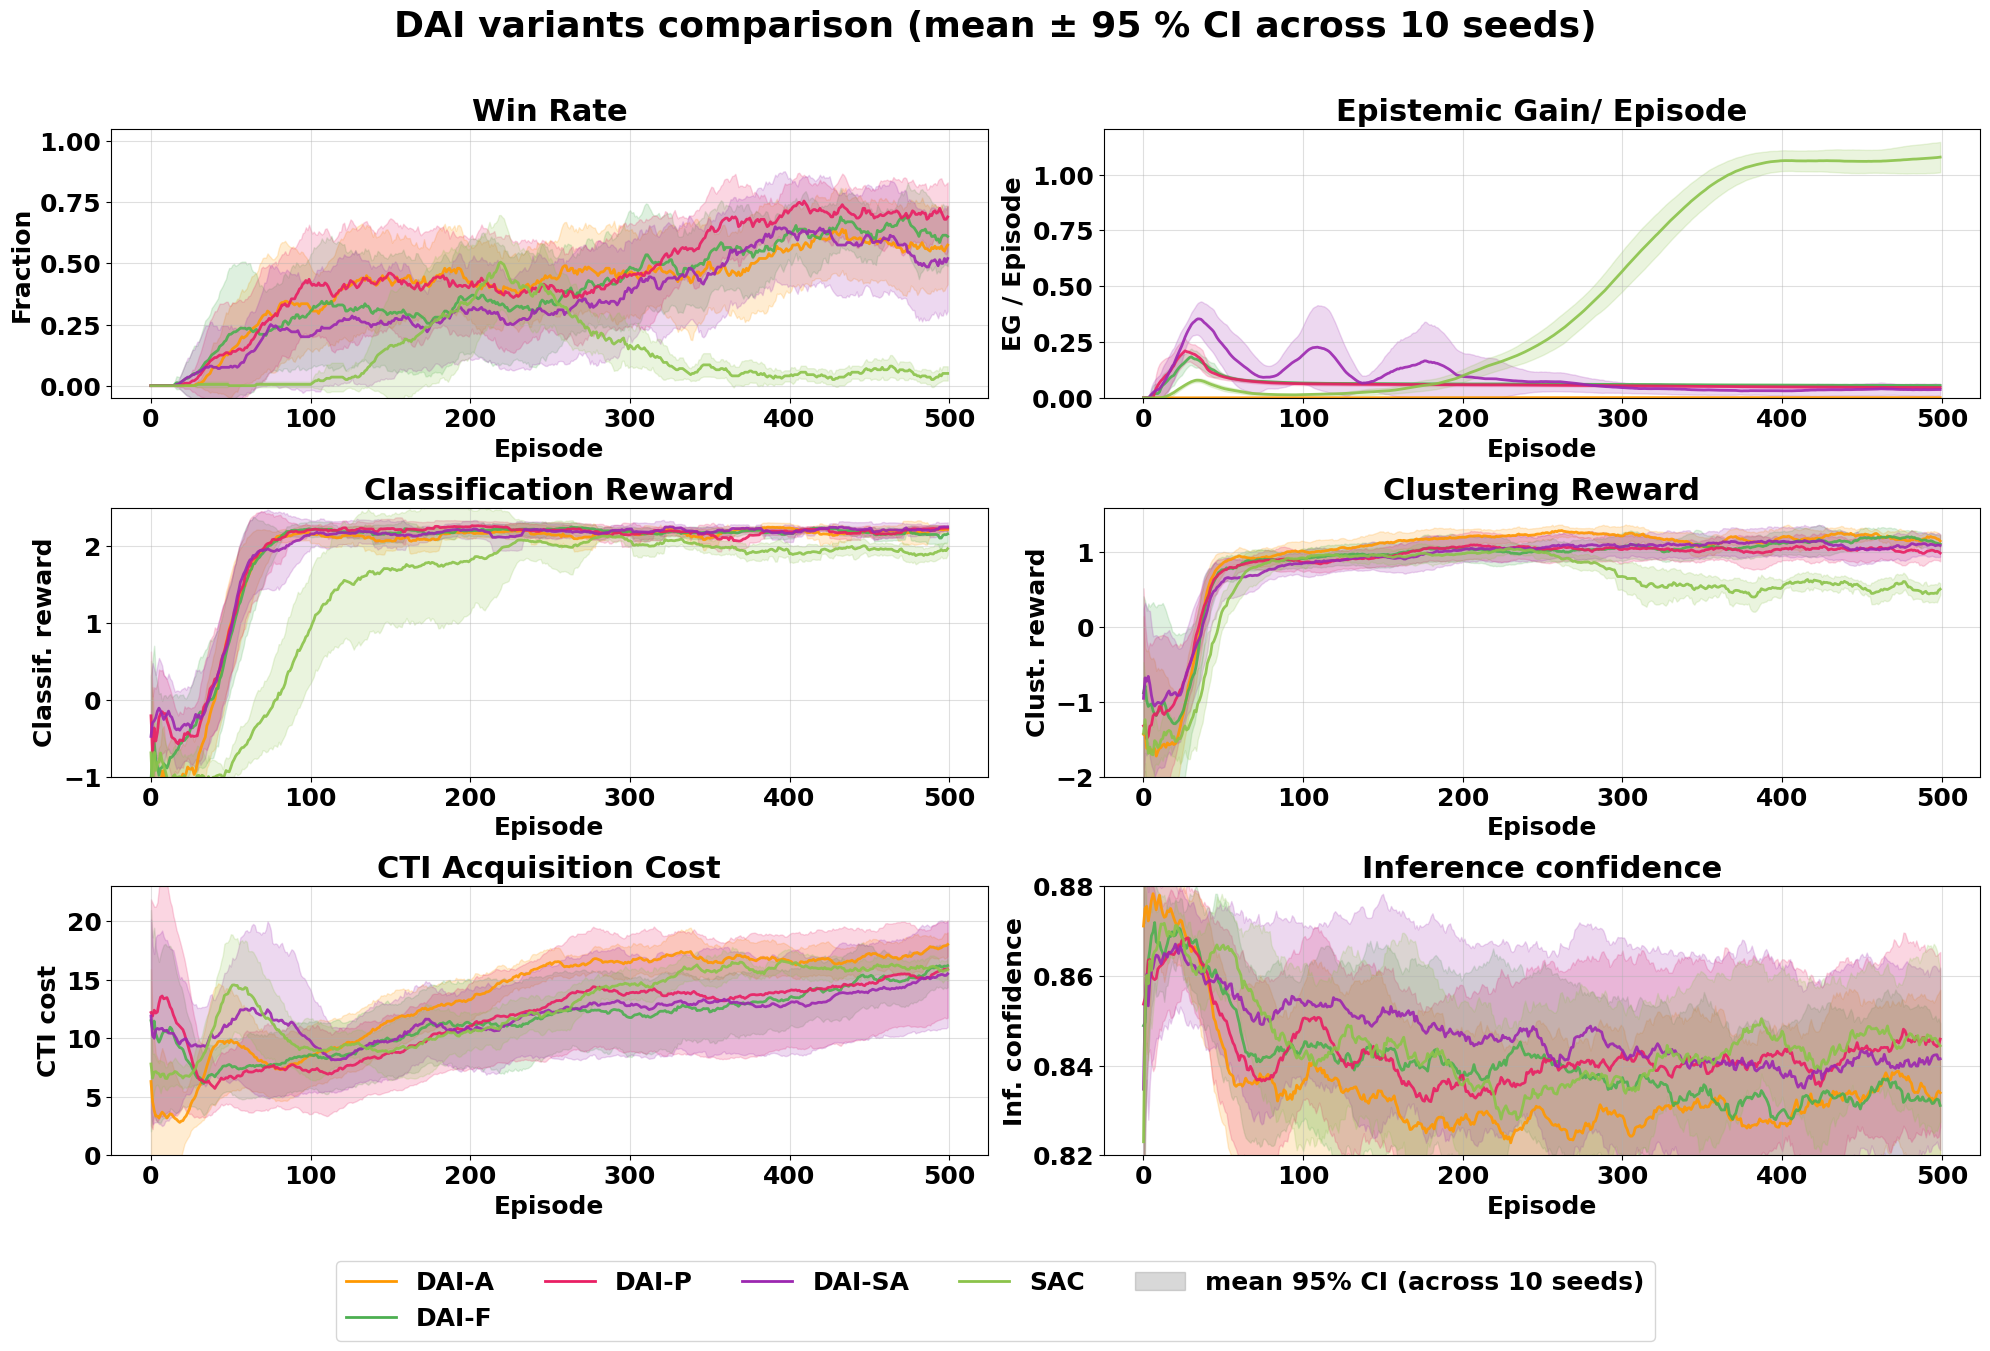

In [ ]:
perf_metrics = [
    {'key': 'win',          'title': 'Win Rate',                 'ylim': (-0.05, 1.05), 'ylabel': 'Fraction'},
    #{'key': 'reward',       'title': 'Mean Step Reward',         'ylim': (-2, None)},
    #{'key': 'n_labels',     'title': 'Labels Bought / Episode',  'ylim': (0, None)},
    #{'key': 'budget_final', 'title': 'Final Episode Budget',     'ylim': None},
    {'key': 'epistemic_gains/mean',         'title': 'Epistemic Gain/ Episode',     'ylim': (0, None), 'ylabel': 'EG / Episode'},
    #{'key': 'n_steps',                      'title': 'Episode Length (steps)',    'ylim': (5, None)},
    {'key': 'classification_reward', 'title': 'Classification Reward',    'ylim': (-1, 2.5), 'ylabel': 'Classif. reward'},
    {'key': 'clustering_reward',     'title': 'Clustering Reward',        'ylim': (-2,None), 'ylabel': 'Clust. reward'},
    {'key': 'cti_cost',              'title': 'CTI Acquisition Cost',      'ylim': (0, 23), 'ylabel': 'CTI cost'},
    {'key': 'inference_confidence', 'title': 'Inference confidence',     'ylim': (0.82,0.88), 'ylabel': 'Inf. confidence'},
]

# Filter agents to include only DAI variants
dai_variants = [agent for agent in agents_found if agent.startswith('DAI') or agent == 'SAC']

plot_metric_grid_v2(
    metrics=perf_metrics,
    n_cols=2,
    suptitle='DAI variants comparison (mean ± 95 % CI across 10 seeds)',
    smooth_window=20,
    agent_subset=dai_variants,
)

---
## Grid Plot 2 — Unknown-Cluster Confidence Tracking

The inference module maintains an EMA confidence estimate for each unknown cluster  
(A, B, C, D).  Buying a label resets the confidence to zero; it then rises again  
as new unlabelled traffic arrives.

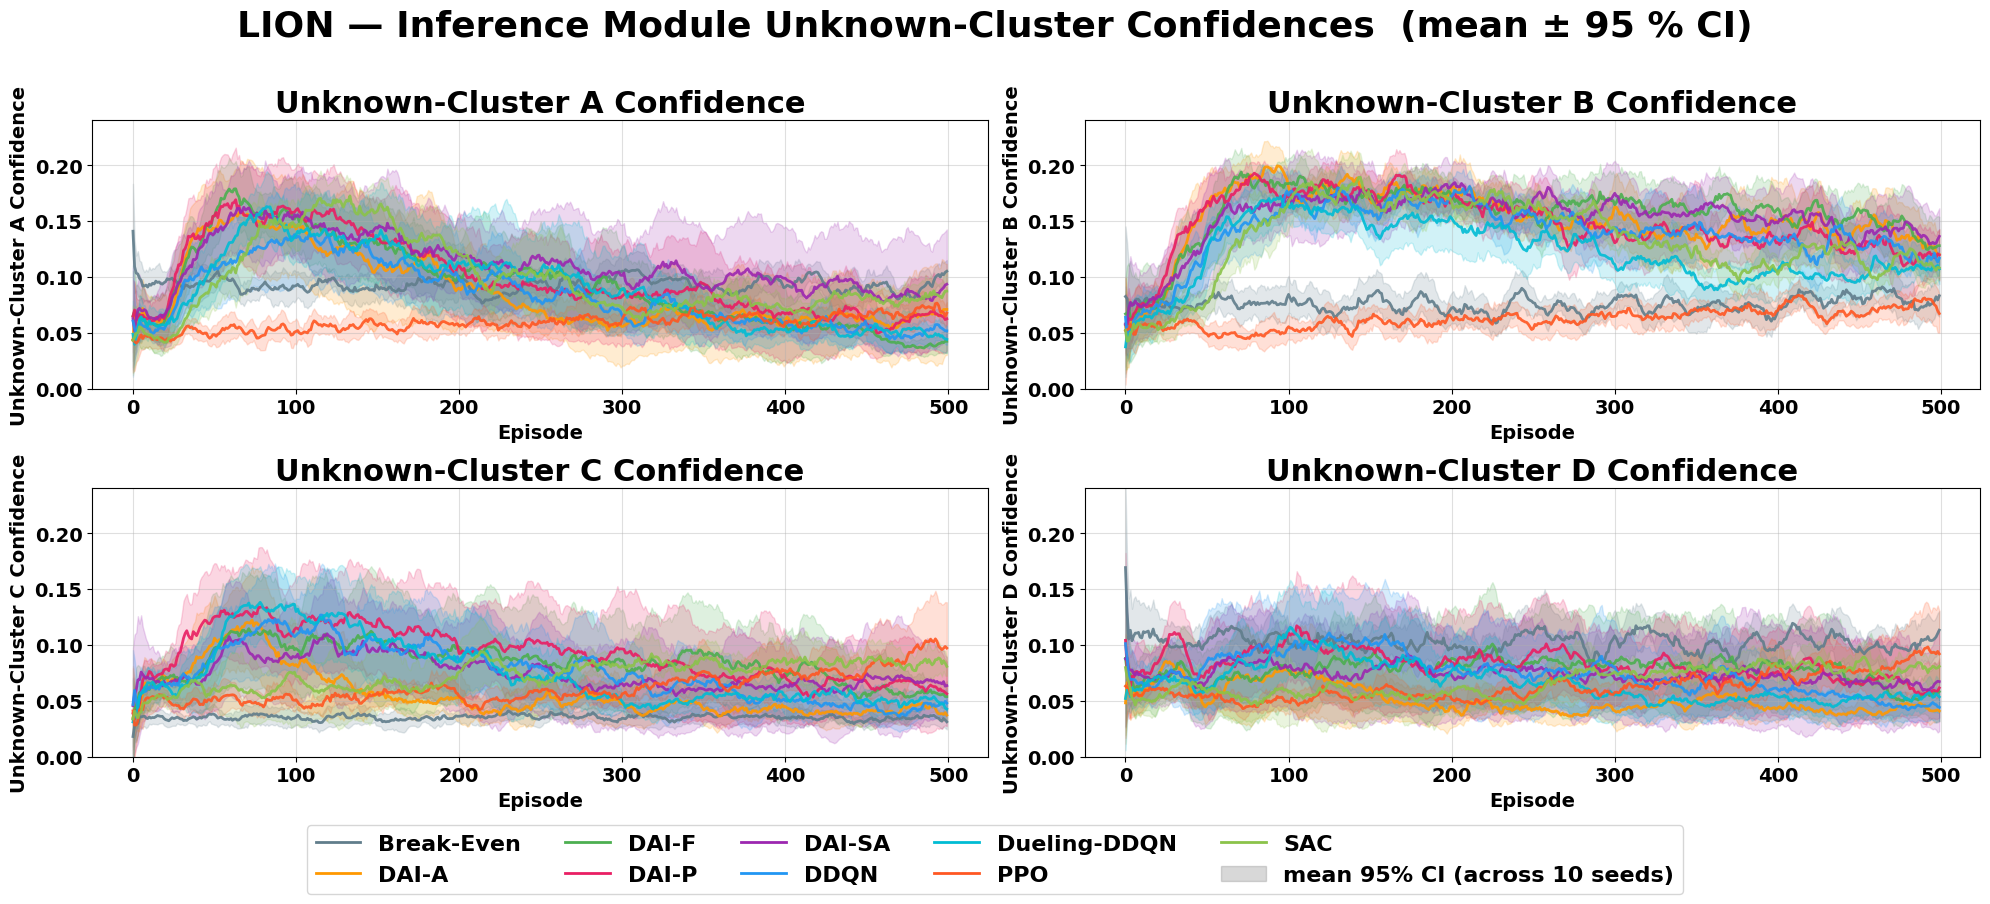

In [ ]:
conf_metrics = [
    {'key': 'unk_confs/A', 'title': 'Unknown-Cluster A Confidence', 'ylim': (0, 0.24)},
    {'key': 'unk_confs/B', 'title': 'Unknown-Cluster B Confidence', 'ylim': (0, 0.24)},
    {'key': 'unk_confs/C', 'title': 'Unknown-Cluster C Confidence', 'ylim': (0, 0.24)},
    {'key': 'unk_confs/D', 'title': 'Unknown-Cluster D Confidence', 'ylim': (0, 0.24)},
]

plot_metric_grid_v2(
    metrics=conf_metrics,
    n_cols=2,
    suptitle='LION — Inference Module Unknown-Cluster Confidences  (mean ± 95 % CI)',
    smooth_window=15,
)

---
## Grid Plot 3 — Epistemic Gains  (DAI agents only)

DAI-based agents (DAI-P, DAI-A, DAI-SA, DAI-F) compute an epistemic gain per action.  
Higher gain → the action is more informative according to the agent's world model.

* **mean** — average epistemic gain across all three action types  
* **block / accept / buy_label** — per-action-type breakdown  
* **buy_A … buy_D** — epistemic value attributed to buying each specific label

DAI agents: ['DAI-A', 'DAI-F', 'DAI-P', 'DAI-SA']


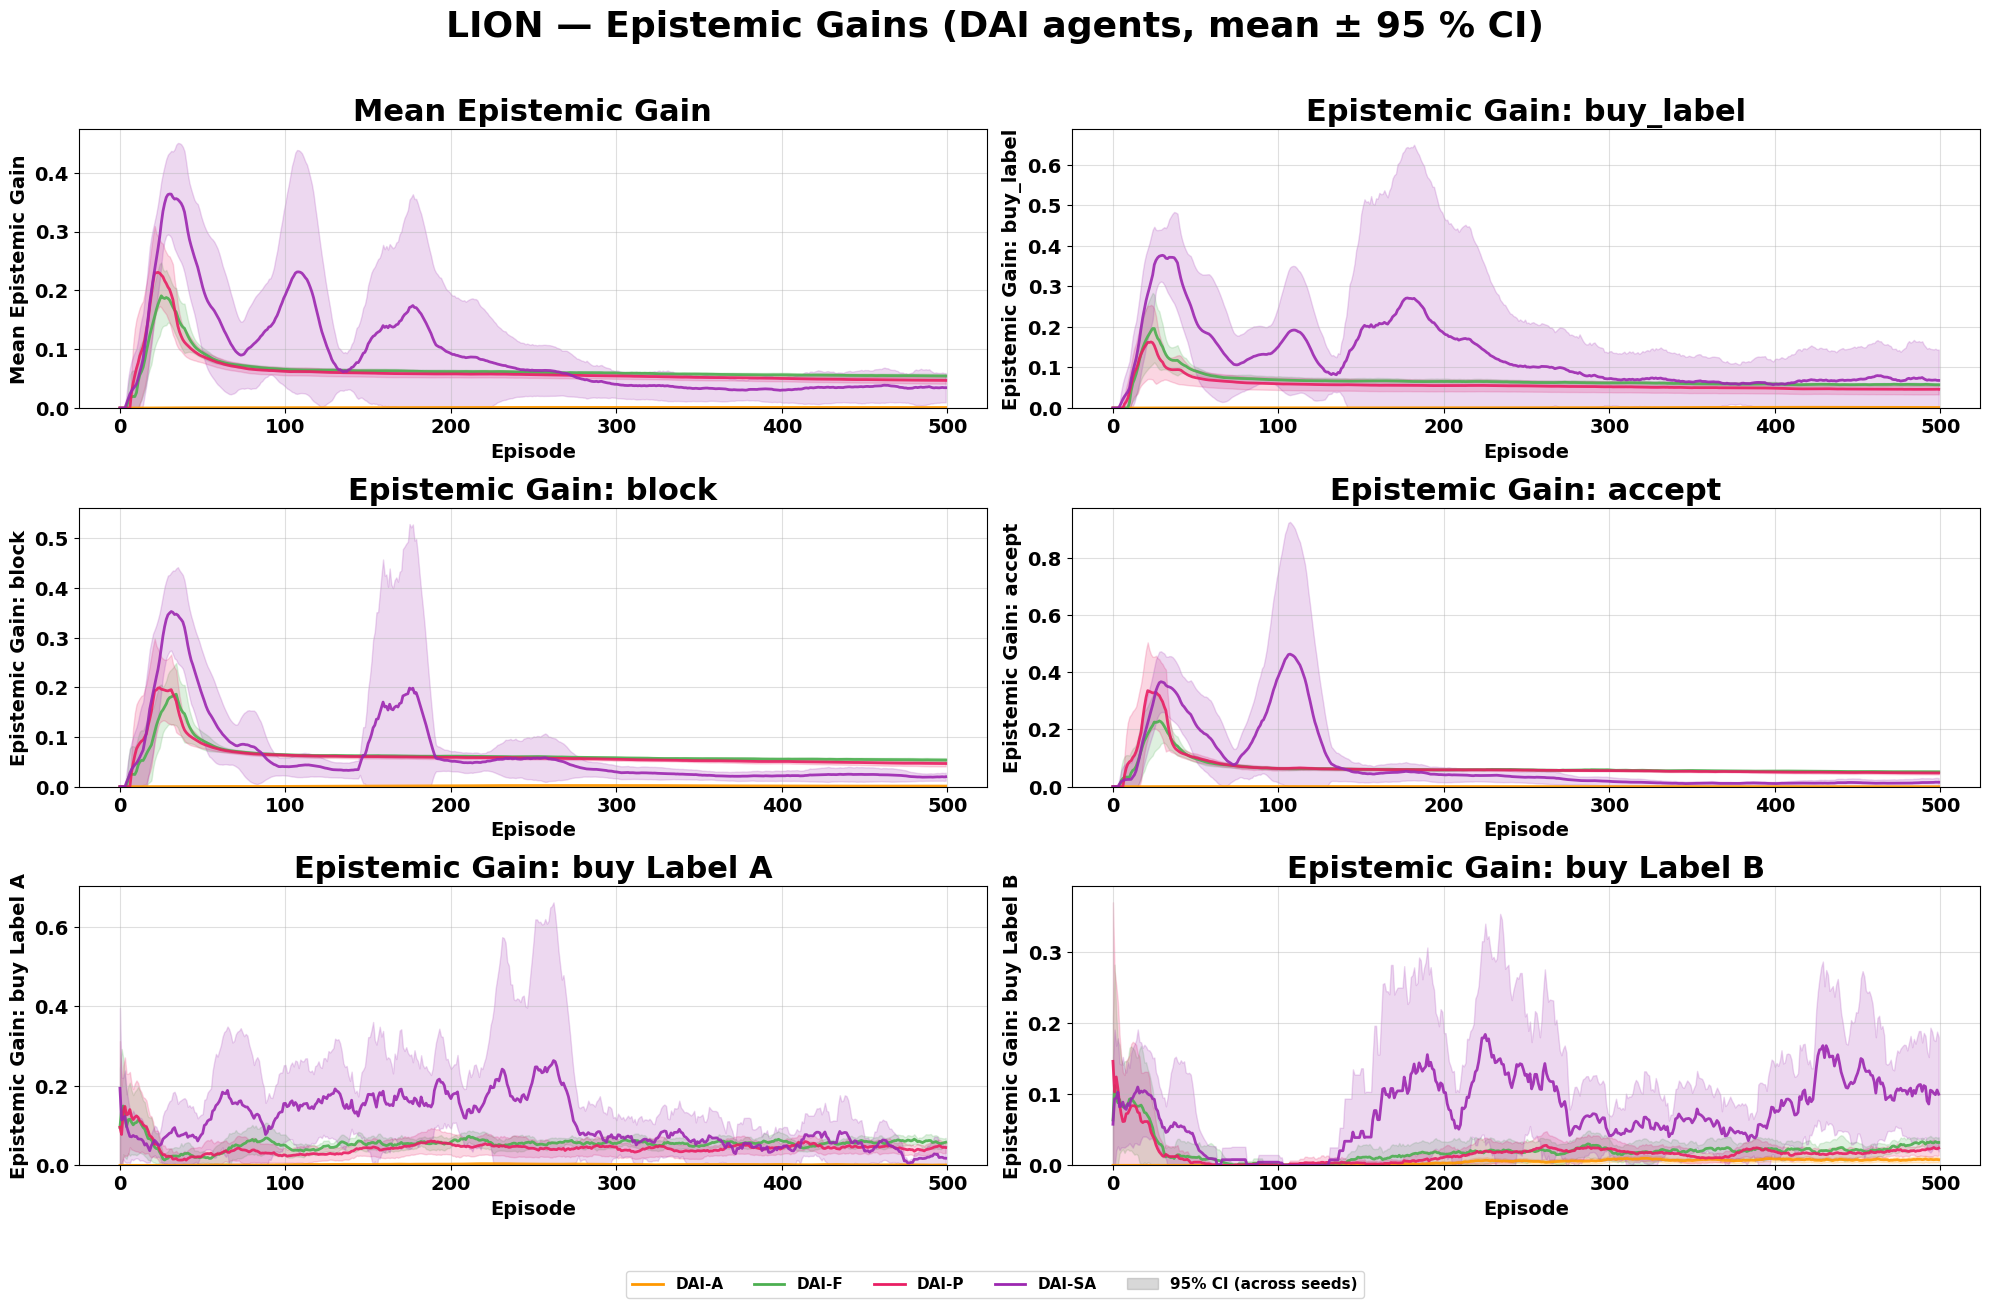

In [ ]:
dai_agents = [a for a in agents_found if a.startswith('DAI')]
print('DAI agents:', dai_agents)

epistemic_metrics = [
    {'key': 'epistemic_gains/mean',      'title': 'Mean Epistemic Gain',         'ylim': (0, None)},
    {'key': 'epistemic_gains/buy_label', 'title': 'Epistemic Gain: buy_label',   'ylim': (0, None)},
    {'key': 'epistemic_gains/block',     'title': 'Epistemic Gain: block',       'ylim': (0, None)},
    {'key': 'epistemic_gains/accept',    'title': 'Epistemic Gain: accept',      'ylim': (0, None)},
    {'key': 'epistemic_gains/buy_A',     'title': 'Epistemic Gain: buy Label A', 'ylim': (0, None)},
    {'key': 'epistemic_gains/buy_B',     'title': 'Epistemic Gain: buy Label B', 'ylim': (0, None)},
]

plot_metric_grid_v2(
    metrics=epistemic_metrics,
    n_cols=2,
    suptitle='LION — Epistemic Gains (DAI agents, mean ± 95 % CI)',
    smooth_window=15,
    agent_subset=dai_agents,
)

---
## Grid Plot 4 (bonus) — Transition-Loss & Episode Length  (DAI agents with trans net)

DAI-P, DAI-A and DAI-F maintain a transition network; its loss (`trans_loss`) shows
how quickly the world model converges.  `n_steps` shows episode length over time.

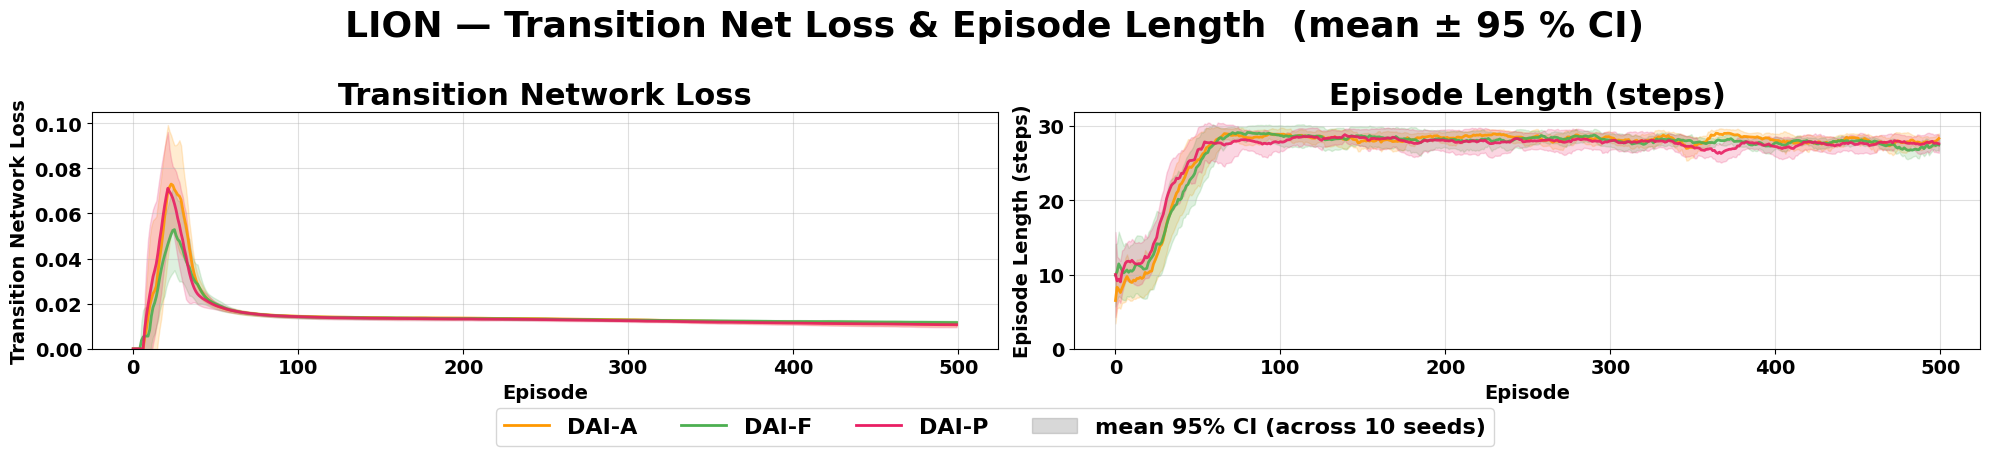

In [ ]:
trans_agents = [a for a in agents_found if a in {'DAI-P', 'DAI-A', 'DAI-F'}]

trans_metrics = [
    {'key': 'trans_loss', 'title': 'Transition Network Loss', 'ylim': (0, None)},
    {'key': 'n_steps',    'title': 'Episode Length (steps)',  'ylim': (0, None)},
]

if trans_agents:
    plot_metric_grid_v2(
        metrics=trans_metrics,
        n_cols=2,
        suptitle='LION — Transition Net Loss & Episode Length  (mean ± 95 % CI)',
        smooth_window=15,
        agent_subset=trans_agents,
    )
else:
    print('No DAI agents with transition network found in this dataset.')

---
## Grid Plot 5 — Reward Decomposition

Splits the total reward into three regimes, equivalent to the old paper's
clustering-reward / classification-reward / CTI-cost breakdown:

* **Sum of Rewards / Episode** — total undiscounted return per episode (old paper top-right)
* **Classification Reward** — mean per-step reward when acting on known or already-labelled flows (informed regime)
* **Clustering Reward** — mean per-step reward when acting on unknown, unlabelled flows (class-agnostic / anomaly regime; negative → ideally → 0)
* **CTI Acquisition Cost** — total label purchase cost paid per episode (should decrease as the agent learns to buy fewer, more targeted labels)

In [ ]:
decomp_metrics = [
    {'key': 'reward_sum',              'title': 'Sum of Rewards / Episode',   'ylim': None},
    {'key': 'classification_reward',   'title': 'Classification Reward',       'ylim': None},
    {'key': 'clustering_reward',       'title': 'Clustering Reward',           'ylim': None},
    {'key': 'cti_cost',                'title': 'CTI Acquisition Cost',        'ylim': (0, None)},
]

plot_metric_grid_v2(
    metrics=decomp_metrics,
    n_cols=2,
    suptitle='LION — Reward Decomposition  (mean ± 95 % CI across 10 seeds)',
    smooth_window=20,
)

---
## Grid Plot 6 — Inference Confidence

Mean per-episode known-class softmax confidence (`conf_k`): the maximum softmax
probability assigned to the predicted known class on each step, averaged over
the episode.  Equivalent to the old paper's lower-left *Inference Confidence* plot.

High values indicate the inference module produces well-separated prototypes and
the agent is operating confidently in the known-class regime.

In [ ]:
conf_metrics_new = [
    {'key': 'inference_confidence', 'title': 'Inference Confidence', 'ylim': (0, 1.0), 'ylabel': 'Mean conf_k'},
    {'key': 'loss',                 'title': 'EFE / Q Regression Loss', 'ylim': (0, None)},
]

plot_metric_grid_v2(
    metrics=conf_metrics_new,
    n_cols=2,
    suptitle='LION — Inference Confidence & Value Regression Loss  (mean ± 95 % CI)',
    smooth_window=20,
)

---
## Appendix — LION Feature Space Visualization

Self-contained plot of the **seven 2-D Gaussian traffic clusters** that make up the
Synthetic LION environment, using the exact parameters from `synthetic_lion.py`.

* **Solid borders** — known classes (K0–K2), pre-trained into the inference module.  
* **Dashed borders** — unknown classes (UA–UD), whose labels the agent must decide whether to buy.  
* **Circle markers** — benign flows; **diamond markers** — malicious flows.  
* Contours at **1σ** (inner) and **2σ** (outer).

The right panel summarises the reward signals and label prices that define the
strategic challenge: the total label cost (19) exceeds the initial episode budget (8),
so the agent can afford at most one or two labels and must choose wisely.


/tmp/ipykernel_1022/3188858711.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


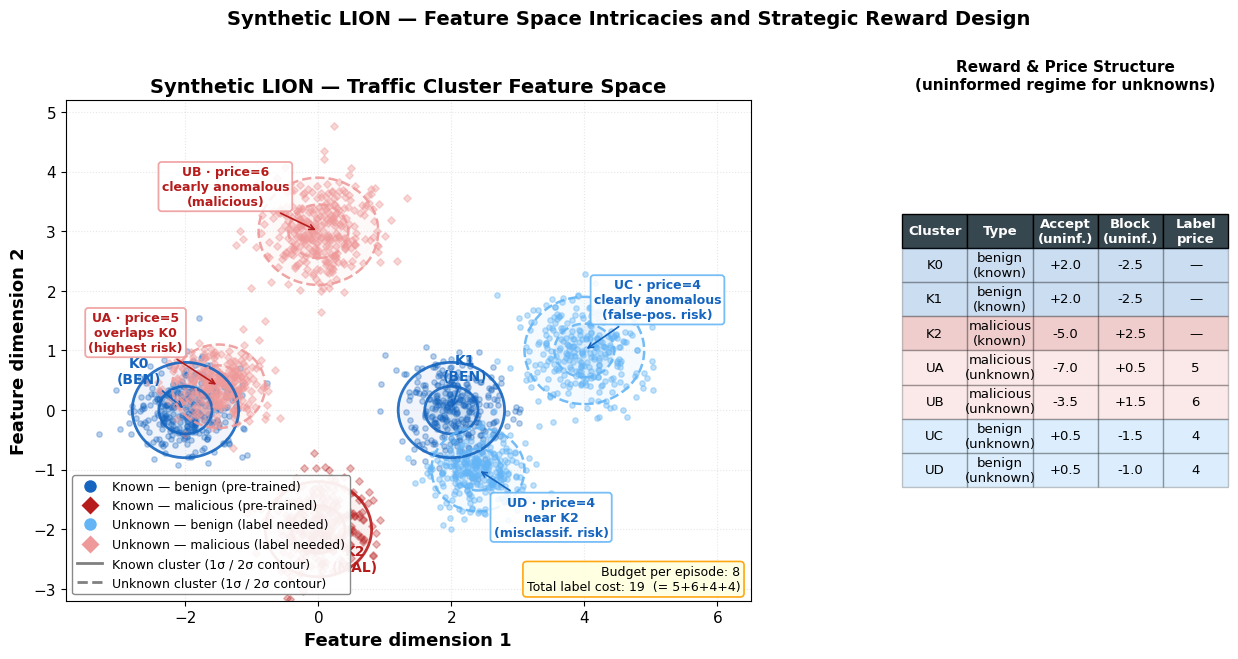

Saved:  lion_feature_space.pdf  and  lion_feature_space.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

# ── Exact parameters from synthetic_lion.py / DataGenerator ─────────────────
KNOWN_MEANS   = np.array([[-2.0,  0.0], [ 2.0,  0.0], [ 0.0, -2.0]])
KNOWN_STDS    = [0.40, 0.40, 0.40]
KNOWN_TYPES   = ['benign', 'benign', 'malicious']

UNKNOWN_MEANS = np.array([[-1.5,  0.4], [ 0.0,  3.0], [ 4.0,  1.0], [ 2.4, -1.0]])
UNKNOWN_STDS  = [0.35, 0.45, 0.45, 0.35]
UNKNOWN_TYPES = ['malicious', 'malicious', 'benign', 'benign']
LABEL_PRICES  = [5.0, 6.0, 4.0, 4.0]
INIT_BUDGET   = 8.0

# Per-cluster uninformed (accept, block) rewards — from CFG in synthetic_lion.py
R_UNINF = {
    'UA': (-7.0,  +0.5),   # malicious; overlaps K0
    'UB': (-3.5,  +1.5),   # malicious; clearly anomalous
    'UC': (+0.5,  -1.5),   # benign;    clearly anomalous (false-positive risk)
    'UD': (+0.5,  -1.0),   # benign;    near K2           (mis-classification risk)
}
# Informed rewards (same for all classes once label is bought / known)
R_INF = {
    'benign':    (+2.0, -2.5),   # (accept, block)
    'malicious': (-5.0, +2.5),
}

# Colour palette
C_K_BEN = '#1565C0'   # deep blue   — known benign
C_K_MAL = '#B71C1C'   # deep red    — known malicious
C_U_BEN = '#64B5F6'   # light blue  — unknown benign
C_U_MAL = '#EF9A9A'   # light red   — unknown malicious

N_SAMPLES = 300

rng = np.random.RandomState(42)


# ── Helper: draw 1σ / 2σ isotropic confidence circles ───────────────────────
def draw_confidence_circles(ax, center, std, color, linestyle='-', lw=2.0):
    for n_std, alpha_fill in [(1, 0.15), (2, 0.06)]:
        ax.add_patch(Ellipse(
            xy=center,
            width=2 * n_std * std, height=2 * n_std * std,
            color=color, alpha=alpha_fill, linewidth=0, zorder=1,
        ))
    for n_std in [1, 2]:
        ax.add_patch(Ellipse(
            xy=center,
            width=2 * n_std * std, height=2 * n_std * std,
            fill=False, edgecolor=color, linewidth=lw,
            linestyle=linestyle, alpha=0.9, zorder=3,
        ))


# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 6.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[2.1, 1], wspace=0.30)
ax  = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Left panel: scatter + confidence ellipses ─────────────────────────────────
# Known classes
for i, (mean, std, ctype) in enumerate(zip(KNOWN_MEANS, KNOWN_STDS, KNOWN_TYPES)):
    color  = C_K_BEN if ctype == 'benign' else C_K_MAL
    marker = 'o' if ctype == 'benign' else 'D'
    pts    = rng.normal(mean, std, size=(N_SAMPLES, 2))
    ax.scatter(pts[:, 0], pts[:, 1], c=color, s=15, alpha=0.30,
               marker=marker, zorder=2)
    draw_confidence_circles(ax, mean, std, color, linestyle='-', lw=2.0)

# Known-class labels (offset chosen to avoid overlap)
K_OFFSETS = [(-0.7,  0.65), ( 0.20,  0.70), ( 0.55, -0.50)]
for i, (mean, ctype) in enumerate(zip(KNOWN_MEANS, KNOWN_TYPES)):
    color  = C_K_BEN if ctype == 'benign' else C_K_MAL
    label  = f'K{i}\n({ctype[:3].upper()})'
    off    = np.array(K_OFFSETS[i])
    ax.annotate(
        label,
        xy=mean, xytext=mean + off,
        fontsize=10, fontweight='bold', color=color,
        ha='center', va='center',
        arrowprops=dict(arrowstyle='->', color=color, lw=1.3),
    )

# Unknown classes
UNK_NAMES   = ['UA', 'UB', 'UC', 'UD']
UNK_NOTES   = [
    'overlaps K0\n(highest risk)',
    'clearly anomalous\n(malicious)',
    'clearly anomalous\n(false-pos. risk)',
    'near K2\n(misclassif. risk)',
]
U_OFFSETS   = [
    (-1.25,  0.90),   # UA
    (-1.40,  0.75),   # UB
    ( 1.10,  0.85),   # UC
    ( 1.10, -0.80),   # UD
]

for i, (mean, std, ctype) in enumerate(zip(UNKNOWN_MEANS, UNKNOWN_STDS, UNKNOWN_TYPES)):
    color  = C_U_BEN if ctype == 'benign' else C_U_MAL
    dcolor = C_K_BEN if ctype == 'benign' else C_K_MAL
    marker = 'o' if ctype == 'benign' else 'D'
    pts    = rng.normal(mean, std, size=(N_SAMPLES, 2))
    ax.scatter(pts[:, 0], pts[:, 1], c=color, s=15, alpha=0.40,
               marker=marker, zorder=2)
    draw_confidence_circles(ax, mean, std, color, linestyle='--', lw=1.8)

    name  = UNK_NAMES[i]
    price = LABEL_PRICES[i]
    ann   = f'{name} · price={price:.0f}\n{UNK_NOTES[i]}'
    off   = np.array(U_OFFSETS[i])
    ax.annotate(
        ann,
        xy=mean, xytext=mean + off,
        fontsize=9, fontweight='bold', color=dcolor,
        ha='center', va='center',
        arrowprops=dict(arrowstyle='->', color=dcolor, lw=1.2),
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor=color, linewidth=1.3, alpha=0.88),
    )

ax.set_xlim(-3.8,  6.5)
ax.set_ylim(-3.2,  5.2)
ax.set_xlabel('Feature dimension 1', fontsize=13, fontweight='bold')
ax.set_ylabel('Feature dimension 2', fontsize=13, fontweight='bold')
ax.set_title('Synthetic LION — Traffic Cluster Feature Space',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.tick_params(labelsize=11)

# Legend
leg_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_K_BEN, markersize=10,
           label='Known — benign (pre-trained)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor=C_K_MAL, markersize=10,
           label='Known — malicious (pre-trained)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_U_BEN, markersize=10,
           label='Unknown — benign (label needed)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor=C_U_MAL, markersize=10,
           label='Unknown — malicious (label needed)'),
    Line2D([0],[0], lw=2.0, linestyle='-',  color='grey', label='Known cluster (1σ / 2σ contour)'),
    Line2D([0],[0], lw=2.0, linestyle='--', color='grey', label='Unknown cluster (1σ / 2σ contour)'),
]
ax.legend(handles=leg_handles, fontsize=9, loc='lower left',
          framealpha=0.92, edgecolor='grey')

ax.text(0.985, 0.015,
        f'Budget per episode: {INIT_BUDGET:.0f}\nTotal label cost: {sum(LABEL_PRICES):.0f}  '
        f'(= {"+".join(str(int(p)) for p in LABEL_PRICES)})',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow',
                  edgecolor='#FFA000', linewidth=1.2, alpha=0.92))

# ── Right panel: reward / price table ────────────────────────────────────────
ax2.axis('off')

col_labels = ['Cluster', 'Type', 'Accept\n(uninf.)', 'Block\n(uninf.)', 'Label\nprice']
table_data = []
# Known classes (informed only — always labelled)
for i, ctype in enumerate(KNOWN_TYPES):
    acc, blk = R_INF[ctype]
    table_data.append([
        f'K{i}',
        f'{ctype}\n(known)',
        f'{acc:+.1f}',
        f'{blk:+.1f}',
        '—',
    ])
# Unknown classes (uninformed until label bought)
for name, ctype, price in zip(UNK_NAMES, UNKNOWN_TYPES, LABEL_PRICES):
    acc_u, blk_u = R_UNINF[name]
    table_data.append([
        name,
        f'{ctype}\n(unknown)',
        f'{acc_u:+.1f}',
        f'{blk_u:+.1f}',
        f'{price:.0f}',
    ])

the_table = ax2.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
the_table.auto_set_font_size(False)
the_table.set_fontsize(9.5)
the_table.scale(1.0, 2.05)

# Style header row
n_cols = len(col_labels)
for j in range(n_cols):
    cell = the_table[0, j]
    cell.set_facecolor('#37474F')
    cell.set_text_props(color='white', fontweight='bold', fontsize=9.5)

# Style data rows by cluster type
row_bg = [C_K_BEN, C_K_BEN, C_K_MAL, C_U_MAL, C_U_MAL, C_U_BEN, C_U_BEN]
for r, bg in enumerate(row_bg):
    for j in range(n_cols):
        the_table[r + 1, j].set_facecolor(bg)
        the_table[r + 1, j].set_alpha(0.22)

ax2.set_title('Reward & Price Structure\n(uninformed regime for unknowns)',
              fontsize=11, fontweight='bold', pad=8)

# ── Save & show ───────────────────────────────────────────────────────────────
plt.suptitle(
    'Synthetic LION — Feature Space Intricacies and Strategic Reward Design',
    fontsize=14, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig('lion_feature_space.pdf', bbox_inches='tight', dpi=300)
plt.savefig('lion_feature_space.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved:  lion_feature_space.pdf  and  lion_feature_space.png')


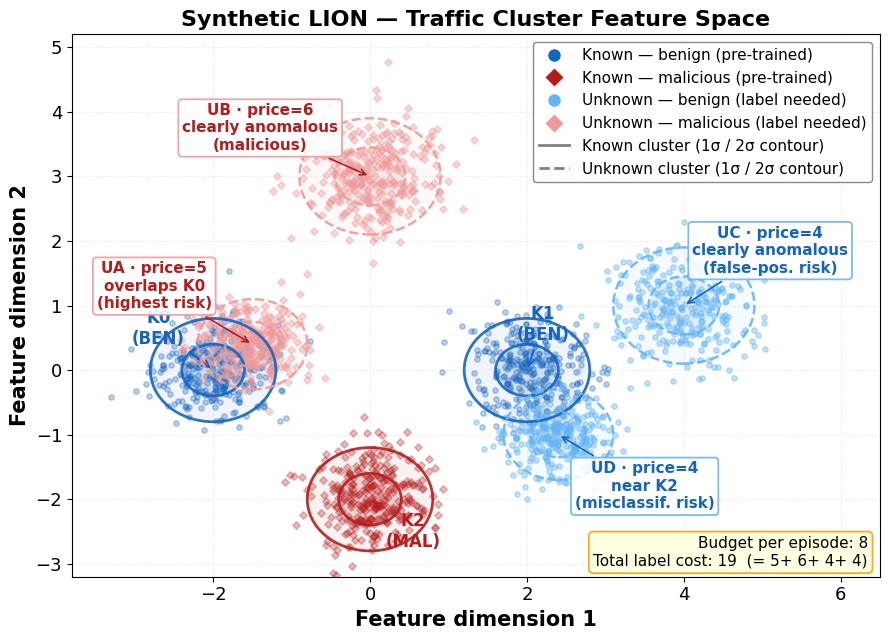

Saved:  lion_feature_space_plot_only.pdf  and  lion_feature_space_plot_only.png


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

# ── Exact parameters from synthetic_lion.py / DataGenerator ─────────────────
KNOWN_MEANS   = np.array([[-2.0,  0.0], [ 2.0,  0.0], [ 0.0, -2.0]])
KNOWN_STDS    = [0.40, 0.40, 0.40]
KNOWN_TYPES   = ['benign', 'benign', 'malicious']

UNKNOWN_MEANS = np.array([[-1.5,  0.4], [ 0.0,  3.0], [ 4.0,  1.0], [ 2.4, -1.0]])
UNKNOWN_STDS  = [0.35, 0.45, 0.45, 0.35]
UNKNOWN_TYPES = ['malicious', 'malicious', 'benign', 'benign']
LABEL_PRICES  = [5.0, 6.0, 4.0, 4.0]
INIT_BUDGET   = 8.0

# Per-cluster uninformed (accept, block) rewards — from CFG in synthetic_lion.py
R_UNINF = {
    'UA': (-7.0,  +0.5),   # malicious; overlaps K0
    'UB': (-3.5,  +1.5),   # malicious; clearly anomalous
    'UC': (+0.5,  -1.5),   # benign;    clearly anomalous (false-positive risk)
    'UD': (+0.5,  -1.0),   # benign;    near K2           (mis-classification risk)
}
# Informed rewards (same for all classes once label is bought / known)
R_INF = {
    'benign':    (+2.0, -2.5),   # (accept, block)
    'malicious': (-5.0, +2.5),
}

# Colour palette
C_K_BEN = '#1565C0'   # deep blue   — known benign
C_K_MAL = '#B71C1C'   # deep red    — known malicious
C_U_BEN = '#64B5F6'   # light blue  — unknown benign
C_U_MAL = '#EF9A9A'   # light red   — unknown malicious

N_SAMPLES = 300

rng = np.random.RandomState(42)


# ── Helper: draw 1σ / 2σ isotropic confidence circles ───────────────────────
def draw_confidence_circles(ax, center, std, color, linestyle='-', lw=2.0):
    for n_std, alpha_fill in [(1, 0.15), (2, 0.06)]:
        ax.add_patch(Ellipse(
            xy=center,
            width=2 * n_std * std, height=2 * n_std * std,
            color=color, alpha=alpha_fill, linewidth=0, zorder=1,
        ))
    for n_std in [1, 2]:
        ax.add_patch(Ellipse(
            xy=center,
            width=2 * n_std * std, height=2 * n_std * std,
            fill=False, edgecolor=color, linewidth=lw,
            linestyle=linestyle, alpha=0.9, zorder=3,
        ))


# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 6.5)) # Adjusted width for single plot
gs  = gridspec.GridSpec(1, 1) # Only one subplot
ax  = fig.add_subplot(gs[0, 0]) # First row, first column

# ── Left panel: scatter + confidence ellipses ─────────────────────────────────
# Known classes
for i, (mean, std, ctype) in enumerate(zip(KNOWN_MEANS, KNOWN_STDS, KNOWN_TYPES)):
    color  = C_K_BEN if ctype == 'benign' else C_K_MAL
    marker = 'o' if ctype == 'benign' else 'D'
    pts    = rng.normal(mean, std, size=(N_SAMPLES, 2))
    ax.scatter(pts[:, 0], pts[:, 1], c=color, s=15, alpha=0.30,
               marker=marker, zorder=2)
    draw_confidence_circles(ax, mean, std, color, linestyle='-', lw=2.0)

# Known-class labels (offset chosen to avoid overlap)
K_OFFSETS = [(-0.7,  0.65), ( 0.20,  0.70), ( 0.55, -0.50)]
for i, (mean, ctype) in enumerate(zip(KNOWN_MEANS, KNOWN_TYPES)):
    color  = C_K_BEN if ctype == 'benign' else C_K_MAL
    label  = f'K{i}\n({ctype[:3].upper()})'
    off    = np.array(K_OFFSETS[i])
    ax.annotate(
        label,
        xy=mean, xytext=mean + off,
        fontsize=12, fontweight='bold', color=color, # Increased fontsize
        ha='center', va='center',
        arrowprops=dict(arrowstyle='->', color=color, lw=1.3),
    )

# Unknown classes
UNK_NAMES   = ['UA', 'UB', 'UC', 'UD']
UNK_NOTES   = [
    'overlaps K0\n(highest risk)',
    'clearly anomalous\n(malicious)',
    'clearly anomalous\n(false-pos. risk)',
    'near K2\n(misclassif. risk)',
]
U_OFFSETS   = [
    (-1.25,  0.90),   # UA
    (-1.40,  0.75),   # UB
    ( 1.10,  0.85),   # UC
    ( 1.10, -0.80),   # UD
]

for i, (mean, std, ctype) in enumerate(zip(UNKNOWN_MEANS, UNKNOWN_STDS, UNKNOWN_TYPES)):
    color  = C_U_BEN if ctype == 'benign' else C_U_MAL
    dcolor = C_K_BEN if ctype == 'benign' else C_K_MAL
    marker = 'o' if ctype == 'benign' else 'D'
    pts    = rng.normal(mean, std, size=(N_SAMPLES, 2))
    ax.scatter(pts[:, 0], pts[:, 1], c=color, s=15, alpha=0.40,
               marker=marker, zorder=2)
    draw_confidence_circles(ax, mean, std, color, linestyle='--', lw=1.8)

    name  = UNK_NAMES[i]
    price = LABEL_PRICES[i]
    ann   = f'{name} · price={price:.0f}\n{UNK_NOTES[i]}'
    off   = np.array(U_OFFSETS[i])
    ax.annotate(
        ann,
        xy=mean, xytext=mean + off,
        fontsize=11, fontweight='bold', color=dcolor, # Increased fontsize
        ha='center', va='center',
        arrowprops=dict(arrowstyle='->', color=dcolor, lw=1.2),
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor=color, linewidth=1.3, alpha=0.88),
    )

ax.set_xlim(-3.8,  6.5)
ax.set_ylim(-3.2,  5.2)
ax.set_xlabel('Feature dimension 1', fontsize=15, fontweight='bold') # Increased fontsize
ax.set_ylabel('Feature dimension 2', fontsize=15, fontweight='bold') # Increased fontsize
ax.set_title('Synthetic LION — Traffic Cluster Feature Space', # Changed suptitle to ax.set_title
             fontsize=16, fontweight='bold') # Increased fontsize
ax.grid(True, alpha=0.30, linestyle=':')
ax.tick_params(labelsize=13) # Increased labelsize

# Legend
leg_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_K_BEN, markersize=10,
           label='Known — benign (pre-trained)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor=C_K_MAL, markersize=10,
           label='Known — malicious (pre-trained)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_U_BEN, markersize=10,
           label='Unknown — benign (label needed)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor=C_U_MAL, markersize=10,
           label='Unknown — malicious (label needed)'),
    Line2D([0],[0], lw=2.0, linestyle='-',  color='grey', label='Known cluster (1σ / 2σ contour)'),
    Line2D([0],[0], lw=2.0, linestyle='--', color='grey', label='Unknown cluster (1σ / 2σ contour)'),
]
ax.legend(handles=leg_handles, fontsize=11, loc='upper right',
          framealpha=0.92, edgecolor='grey') # Increased fontsize

ax.text(0.985, 0.015,
        f'Budget per episode: {INIT_BUDGET:.0f}\nTotal label cost: {sum(LABEL_PRICES):.0f}  '
        f'(= {"+ ".join(str(int(p)) for p in LABEL_PRICES)})',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=11, # Increased fontsize
        bbox=dict(boxstyle='round', facecolor='lightyellow',
                  edgecolor='#FFA000', linewidth=1.2, alpha=0.92))

# ── Save & show ───────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('lion_feature_space_plot_only.pdf', bbox_inches='tight', dpi=300) # Updated filename
plt.savefig('lion_feature_space_plot_only.png', bbox_inches='tight', dpi=300) # Updated filename
plt.show()
print('Saved:  lion_feature_space_plot_only.pdf  and  lion_feature_space_plot_only.png')


---
## Profiling — Inference & Training Step Times

`profiling/act_time_ms` is the mean wall-clock cost of `agent.act()` per step (forward-pass only).  
`profiling/train_time_ms` is the mean wall-clock cost of `agent.train_step()` per step (full backward pass).  
`label_A_step` is the episode step at which label A was purchased (`-1` = not bought that episode);  
its rolling mean shows how early in the episode agents commit to buying label A over time.

In [ ]:
timing_metrics = [
    {
        'key':    'profiling/act_time_ms',
        'title':  'Inference Time  (act)',
        'ylabel': 'ms / step',
        'ylim':   (0, None),
    },
    {
        'key':    'profiling/train_time_ms',
        'title':  'Training Step Time  (train_step)',
        'ylabel': 'ms / step',
        'ylim':   (0, None),
    },
    {
        'key':    'label_A_step',
        'title':  'Step at Which Label A is Bought\n(−1 = not bought this episode)',
        'ylabel': 'Episode step',
        'ylim':   None,
    },
]

# Guard: check that at least one timing column exists in the fetched data
_timing_found = any(
    any(col.startswith(m['key']) for col in wide.columns)
    for m in timing_metrics
    for wide in agent_data.values()
)

if _timing_found:
    plot_metric_grid_v2(
        metrics=timing_metrics,
        n_cols=2,
        suptitle='Profiling — Inference & Training Times, Label-A Step  (mean ± 95 % CI)',
        smooth_window=15,
    )
else:
    print(
        "Timing columns not found in the fetched runs — re-run experiments with the "
        "updated synthetic_lion.py (adds profiling/* and label_A_step metrics) and "
        "update GROUP / WANDB_PROJECT above to point at the new run group."
    )

---
## Label-Sequence Panoramic

For each run W&B stores a **summary** (not a per-episode metric) with:

| Key | Meaning |
|-----|---------|
| `label_seq/most_common` | Most frequent label-purchase ordering across all **won** episodes (e.g. `A→C`) |
| `label_seq/most_common_count` | How many won episodes showed this sequence |
| `label_seq/won_episodes` | Total won episodes across the whole run |

The cells below build two complementary views:

1. **Sequence frequency heatmap** — for each agent (rows) and sequence string (columns),  
   how many of the 10 seeds had that sequence as their modal winning pattern.
2. **Dominant-sequence bar chart** — the single most popular sequence per agent  
   (majority vote across seeds) with the fraction of seeds that agree.

In [ ]:
import collections as _col

# ── 1. Harvest label_seq summary values from already-fetched run objects ──────
seq_records = []
for run in all_runs:
    agent_name  = run.config.get('agent', 'unknown')
    seed        = run.config.get('seed', -1)
    summary     = dict(run.summary)
    most_common = summary.get('label_seq/most_common')
    seq_count   = summary.get('label_seq/most_common_count')
    won_eps     = summary.get('label_seq/won_episodes')
    if most_common is not None and won_eps:
        seq_records.append({
            'agent':    agent_name,
            'seed':     seed,
            'sequence': most_common,
            'count':    seq_count,
            'won':      won_eps,
            'fraction': seq_count / won_eps,
        })

if not seq_records:
    print(
        "No label_seq summary data found in this run group.\n"
        "Re-run experiments with the updated synthetic_lion.py and point the "
        "GROUP variable above at the new run group."
    )
else:
    seq_df = pd.DataFrame(seq_records)
    color_map = get_color_map(agents_found)

    # ── 2. Pivot: rows = agent, columns = sequence, values = # seeds ──────────
    pivot = (
        seq_df.groupby(['agent', 'sequence'])
              .size()
              .unstack(fill_value=0)
    )
    # Sort columns by total frequency across all agents
    pivot = pivot[pivot.sum().sort_values(ascending=False).index]

    n_agents, n_seqs = pivot.shape
    fig_h = max(3, n_agents * 0.55 + 2.5)
    fig_w = max(8, n_seqs * 1.1 + 3)

    fig, axes = plt.subplots(1, 2, figsize=(fig_w + 8, fig_h),
                             gridspec_kw={'width_ratios': [fig_w, 5]})

    # ── Heatmap (left) ────────────────────────────────────────────────────────
    ax_heat = axes[0]
    im = ax_heat.imshow(pivot.values, aspect='auto', cmap='YlOrRd',
                        vmin=0, vmax=pivot.values.max())
    ax_heat.set_xticks(range(n_seqs))
    ax_heat.set_xticklabels(pivot.columns, rotation=45, ha='right',
                            fontsize=11, fontweight='bold')
    ax_heat.set_yticks(range(n_agents))
    ax_heat.set_yticklabels(pivot.index, fontsize=12, fontweight='bold')
    ax_heat.set_xlabel('Label-purchase sequence  (A→B means A bought before B)',
                       fontsize=12, fontweight='bold')
    ax_heat.set_title('# seeds where sequence was\nmost common  (won episodes only)',
                      fontsize=13, fontweight='bold')
    for r in range(n_agents):
        for c in range(n_seqs):
            val = pivot.values[r, c]
            if val > 0:
                ax_heat.text(c, r, str(val), ha='center', va='center',
                             fontsize=10, fontweight='bold',
                             color='white' if val >= pivot.values.max() * 0.6 else 'black')
    fig.colorbar(im, ax=ax_heat, label='# seeds', fraction=0.03, pad=0.03)

    # ── Dominant-sequence bar chart (right) ───────────────────────────────────
    ax_bar = axes[1]
    dominant      = pivot.idxmax(axis=1)
    dom_count     = pivot.max(axis=1)
    n_seeds_total = seq_df['seed'].nunique()
    dom_frac      = dom_count / n_seeds_total

    bar_agents = list(dominant.index)
    bar_seqs   = list(dominant.values)
    bar_fracs  = list(dom_frac.values)
    bar_colors = [color_map.get(a, 'steelblue') for a in bar_agents]

    ax_bar.barh(range(len(bar_agents)), bar_fracs, color=bar_colors,
                edgecolor='white', linewidth=1.2, alpha=0.88)
    ax_bar.set_yticks(range(len(bar_agents)))
    ax_bar.set_yticklabels(bar_agents, fontsize=12, fontweight='bold')
    ax_bar.set_xlabel('Fraction of seeds with dominant sequence', fontsize=11, fontweight='bold')
    ax_bar.set_xlim(0, 1.05)
    ax_bar.axvline(0.5, color='grey', linestyle='--', linewidth=1.2, alpha=0.6)
    ax_bar.set_title('Dominant sequence per agent\n(majority vote across seeds)',
                     fontsize=13, fontweight='bold')
    ax_bar.grid(True, axis='x', alpha=0.35)
    for i, (seq, frac) in enumerate(zip(bar_seqs, bar_fracs)):
        ax_bar.text(frac + 0.02, i, seq, va='center', fontsize=10, fontweight='bold')

    plt.suptitle(
        'Label-Purchase Sequence Panoramic  (won episodes only)',
        fontsize=16, fontweight='bold', y=1.01,
    )
    plt.tight_layout()
    plt.show()

    # ── 3. Summary table ──────────────────────────────────────────────────────
    print("\nPer-agent dominant sequence  (majority vote across seeds):\n")
    summary_rows = []
    for agent in sorted(pivot.index):
        top_seq   = pivot.loc[agent].idxmax()
        top_seeds = pivot.loc[agent].max()
        avg_frac  = seq_df[seq_df['agent'] == agent]['fraction'].mean()
        avg_won   = seq_df[seq_df['agent'] == agent]['won'].mean()
        summary_rows.append({
            'Agent':            agent,
            'Dominant Seq':     top_seq,
            'Seeds agreeing':   f"{int(top_seeds)}/{n_seeds_total}",
            'Seq consistency':  f"{avg_frac:.1%}",
            'Avg won eps':      f"{avg_won:.0f}",
        })
    print(pd.DataFrame(summary_rows).to_string(index=False))